# Cardiac Risk Prediction Lab
**Module 3 · Lab 1 — Are You Built For AI?**

Welcome, healthcare analyst! Your hospital wants a tool that helps doctors flag
patients with a high risk of heart disease. You'll use a real dataset of about
300 patient records to train and evaluate a simple AI model.

### What you'll do

1. **Load and explore** the UCI Cleveland Heart Disease dataset with `pandas`.
2. **Train a logistic regression model** using features that *you* choose.
3. **Evaluate** the model with accuracy, precision, and recall — and connect each
   number to a real clinical situation.
4. **Interpret** the model's feature weights and decide if you'd actually trust it.

> 🩺 **Reminder:** This is a learning exercise. The model you build here is **not**
> a medical device and must not be used to make real clinical decisions.

## Setup (Colab users — run this first)

If you're running this notebook in **Google Colab**, run the cell below once to
install the right packages and download the dataset. Local Jupyter users who
already followed the README setup can skip this cell.

In [1]:
# Run this cell once if you're in Google Colab.
# If you're running locally and already ran download_data.py, you can skip it.

import sys, os, subprocess, urllib.request

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # Install pinned versions of the libraries we need.
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'pandas==2.2.2', 'scikit-learn==1.5.1',
                    'matplotlib==3.9.1', 'seaborn==0.13.2'], check=True)
    # Download the dataset to the current working directory.
    url = ('https://archive.ics.uci.edu/ml/'
           'machine-learning-databases/heart-disease/processed.cleveland.data')
    urllib.request.urlretrieve(url, 'processed.cleveland.data')
    print('Colab setup complete.')
else:
    print('Local run — make sure you executed: python data/download_data.py')

Colab setup complete.


---
## Step 1 — Load and explore the data

Before training any model, you need to understand the data you're working with.
A doctor wouldn't trust a tool they couldn't explain — and neither should you.

### 1a. Import the libraries we'll use

- **pandas** — for loading and exploring data tables.
- **matplotlib** and **seaborn** — for making charts.
- **scikit-learn** pieces — for splitting data, training, and evaluating the model.

In [ ]:
import micropip
await micropip.install(['seaborn'])

In [ ]:
# In JupyterLite, heart.csv is served alongside the notebook.
# No download needed — just read it directly.
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_pyodide.html5_canvas_backend')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix)

sns.set_theme(style='whitegrid')

cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv('heart.csv')
print(f'Loaded {len(df)} patient records.')
df.head()

Libraries loaded.


### 1b. Load the dataset

We'll load `heart.csv` — the cleaned file produced by `data/download_data.py`.

**Heads-up:** if you're in Colab, the cleaned `heart.csv` doesn't exist yet — the
setup cell only downloaded the raw UCI file. The cell below handles both cases.

In [3]:
import os

# Look in the most common locations for the cleaned CSV.
candidates = ['../data/heart.csv', 'heart.csv', 'data/heart.csv']
csv_path = next((p for p in candidates if os.path.exists(p)), None)

if csv_path is None and os.path.exists('processed.cleveland.data'):
    # Colab path: build heart.csv from the raw file on the fly.
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
            'exang','oldpeak','slope','ca','thal','target']
    df = pd.read_csv('processed.cleveland.data', header=None,
                     names=cols, na_values='?').dropna().reset_index(drop=True)
    df['target'] = (df['target'] > 0).astype(int)
    df.to_csv('heart.csv', index=False)
    csv_path = 'heart.csv'

df = pd.read_csv(csv_path)
print(f'Loaded {len(df)} patient records from {csv_path}')
df.head()

Loaded 297 patient records from heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 1c. What does each column mean?

The dataset has 13 features and 1 target label. A few of the names are doctor
shorthand — here's a translation:

| Column | What it means |
|---|---|
| `age` | Patient age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest-pain type (1–4) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = yes) |
| `restecg` | Resting electrocardiogram result (0–2) |
| `thalach` | Maximum heart rate reached during exercise |
| `exang` | Exercise-induced chest pain (1 = yes) |
| `oldpeak` | ST depression during exercise (heart-stress signal) |
| `slope` | Slope of the peak exercise ST segment |
| `ca` | Number of major vessels colored by a special X-ray (0–3) |
| `thal` | Blood-flow test result (3 = normal, 6 = fixed defect, 7 = reversible) |
| `target` | **What we predict.** 0 = no heart disease, 1 = heart disease |

*Jargon check:* an **ST depression** is a particular dip on a heart-rhythm tracing
that doctors watch for during exercise tests. You don't need to understand the
biology — just know it's a number that tends to be higher in sicker patients.

### 1d. Quick sanity checks

Run these next three cells to get a feel for the data.

In [4]:
# Shape: how many rows (patients) and columns (features + target)?
df.shape

(297, 14)

In [5]:
# Summary statistics for each column.
df.describe().round(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0
mean,54.5,0.7,3.2,131.7,247.4,0.1,1.0,149.6,0.3,1.1,1.6,0.7,4.7,0.5
std,9.0,0.5,1.0,17.8,52.0,0.4,1.0,22.9,0.5,1.2,0.6,0.9,1.9,0.5
min,29.0,0.0,1.0,94.0,126.0,0.0,0.0,71.0,0.0,0.0,1.0,0.0,3.0,0.0
25%,48.0,0.0,3.0,120.0,211.0,0.0,0.0,133.0,0.0,0.0,1.0,0.0,3.0,0.0
50%,56.0,1.0,3.0,130.0,243.0,0.0,1.0,153.0,0.0,0.8,2.0,0.0,3.0,0.0
75%,61.0,1.0,4.0,140.0,276.0,0.0,2.0,166.0,1.0,1.6,2.0,1.0,7.0,1.0
max,77.0,1.0,4.0,200.0,564.0,1.0,2.0,202.0,1.0,6.2,3.0,3.0,7.0,1.0


In [6]:
# How many patients have the disease vs not?
df['target'].value_counts()

,count
target,
0,160
1,137


### 1e. Visualize the target balance

If one class is much rarer than the other, the model could 'cheat' by always
guessing the common one. Let's check.

/tmp/ipykernel_7548/294177462.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette=['#4C9F70', '#D9534F'])
/tmp/ipykernel_7548/294177462.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No disease (0)', 'Heart disease (1)'])


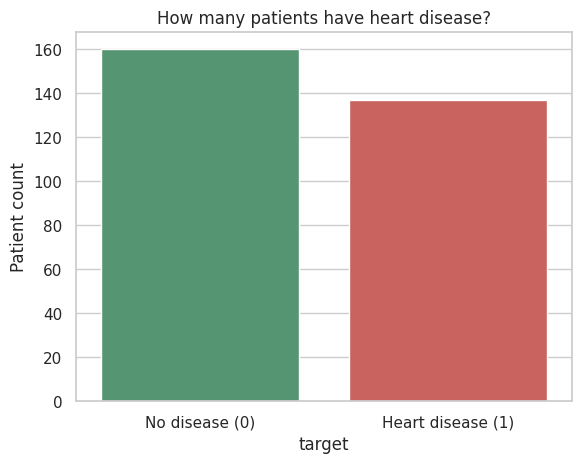

In [7]:
ax = sns.countplot(x='target', data=df, palette=['#4C9F70', '#D9534F'])
ax.set_xticklabels(['No disease (0)', 'Heart disease (1)'])
ax.set_title('How many patients have heart disease?')
ax.set_ylabel('Patient count')
plt.show()

### 1f. Your turn — explore one feature

Pick **one** feature you're curious about (try `chol`, `thalach`, `age`, or
`oldpeak`) and replace `FEATURE` below with its column name. Does the chart
suggest the feature differs between healthy and sick patients?

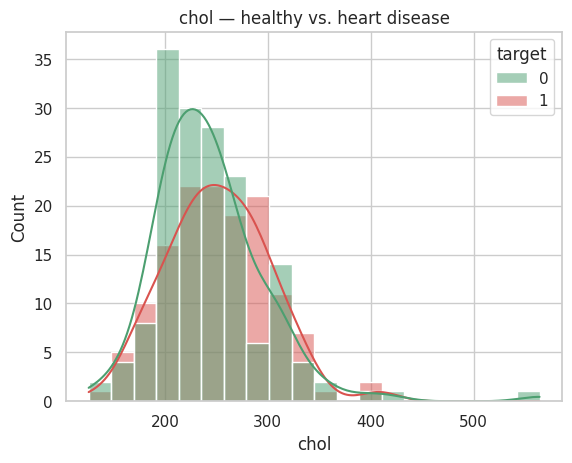

In [19]:
FEATURE = 'chol'  # <-- change me

sns.histplot(data=df, x=FEATURE, hue='target', kde=True,
             palette=['#4C9F70', '#D9534F'], bins=20)
plt.title(f'{FEATURE} — healthy vs. heart disease')
plt.show()

---
## Step 2 — Train a logistic regression model

**Logistic regression** sounds fancy but the idea is simple: the model assigns a
weight (a number) to each feature, multiplies the feature values by their
weights, sums them up, and squashes the total into a probability between 0 and 1.

During training, scikit-learn tweaks those weights over and over so the model's
predictions match the true labels as closely as possible. That's the same idea
as the random-weights → updated-weights story from the lab slides.

### 2a. Choose your features

**Your decision:** which features should the model see? Start with the list
below (it's a reasonable beginner set), then come back later and try adding or
removing features to see how the score changes.

Why does the choice matter? In real ML projects, more features isn't always
better — irrelevant features add noise and can confuse the model.

In [20]:
# Edit this list to choose which features the model can use.
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol',
                'thalach', 'exang', 'slope']

X = df[feature_cols]   # input features
y = df['target']       # what we're predicting

print(f'Using {len(feature_cols)} features: {feature_cols}')

Using 8 features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'slope']


### 2b. Split the data into training and testing sets

We hold out 20% of the patients as a **test set**. The model never sees these
rows during training, so when we check its performance on them later we get a
fair idea of how it would behave on new patients.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% of rows for testing
    random_state=42,  # so everyone gets the same split
    stratify=y,       # keep the same disease ratio in both halves
)

print(f'Training patients: {len(X_train)}')
print(f'Testing patients:  {len(X_test)}')

Training patients: 237
Testing patients:  60


### 2c. Scale the features

Cholesterol values are in the hundreds; `sex` is 0 or 1. Without scaling, the
model would over-react to large-number features just because they're big. A
**StandardScaler** rescales every feature to roughly the same range.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # use the SAME scaling on test data

### 2d. Fit the model

One line of code does the actual training. Behind the scenes, scikit-learn is
looping through the training patients many times and nudging the weights, just
like the slides showed.

In [22]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model trained!')

Model trained!


---
## Step 3 — Evaluate the model

Time to find out how well your model actually does on patients it has never
seen before. We'll look at three numbers, but the numbers alone don't tell the
whole story — what matters is what each one means *in a hospital*.

### 3a. What these metrics mean — in plain English

Imagine the model is screening 100 patients in a cardiology clinic.

| Metric | One-line definition | What it tells you in this clinic |
|---|---|---|
| **Accuracy** | Fraction of patients the model labels correctly. | Overall "how often is it right?" — but it can be misleading if the disease is rare. |
| **Precision** | Of the patients the model **flags as sick**, what fraction really are sick? | High precision = few false alarms. Important when extra tests are expensive or scary. |
| **Recall** *(also called sensitivity)* | Of the patients who **really are sick**, what fraction did the model catch? | High recall = few missed cases. *Usually the most important metric in medicine* — missing a heart-disease patient is far worse than a false alarm. |

> ⚖️ **Trade-off:** you can almost always raise one of these by lowering another.
> A model that flags everyone as sick will have 100% recall but terrible
> precision. Part of your job as the analyst is to pick a balance that fits the
> clinical situation.

### 3b. Generate predictions on the test set

In [13]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of disease

# Peek at the first 10 predictions vs. the true labels.
preview = pd.DataFrame({
    'predicted_label': y_pred[:10],
    'predicted_prob':  y_prob[:10].round(2),
    'true_label':      y_test.iloc[:10].values,
})
preview

,predicted_label,predicted_prob,true_label
0,0,0.04,0
1,0,0.12,0
2,1,0.64,0
3,0,0.18,0
4,1,0.56,0
5,0,0.03,0
6,1,0.70,1
7,0,0.03,0
8,1,0.73,1
9,0,0.09,0


### 3c. Calculate accuracy, precision, and recall

In [14]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)

print(f'Accuracy : {acc:.2%}')
print(f'Precision: {prec:.2%}')
print(f'Recall   : {rec:.2%}')

Accuracy : 81.67%
Precision: 81.48%
Recall   : 78.57%


### 3d. Look at the confusion matrix

A confusion matrix breaks the predictions into four boxes:

- **TN** (top-left): healthy patients the model correctly labeled healthy.
- **FP** (top-right): healthy patients the model **wrongly flagged as sick**.
- **FN** (bottom-left): sick patients the model **missed**. *Most dangerous.*
- **TP** (bottom-right): sick patients the model correctly caught.

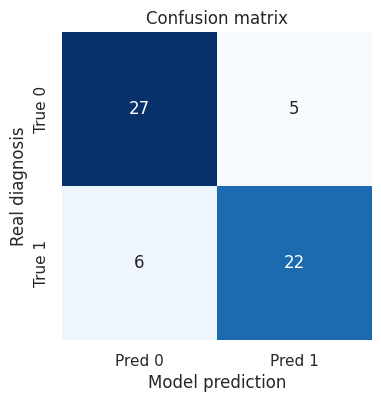

In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'], ax=ax)
ax.set_xlabel('Model prediction')
ax.set_ylabel('Real diagnosis')
ax.set_title('Confusion matrix')
plt.show()

**Pause and think.** Look at the FN box (missed cases) and the FP box (false
alarms). Which kind of error is worse for the hospital? Why?

---
## Step 4 — Interpret the model

Doctors are far more likely to trust an AI tool when they understand **why** it
made a decision. Logistic regression is nice because each feature has a single
weight (called a *coefficient*) that tells you how much that feature pushes the
prediction up or down.

### 4a. Pull out the feature coefficients

**How to read this table:**
- A **positive** coefficient means *higher values of the feature → higher predicted risk*.
- A **negative** coefficient means *higher values of the feature → lower predicted risk*.
- The **larger the absolute value**, the bigger the influence on the prediction.

In [16]:
coef_table = (pd.DataFrame({
        'feature': feature_cols,
        'coefficient': model.coef_[0],
    })
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
    .reset_index(drop=True))

coef_table.round(3)

,feature,coefficient
0,sex,0.772
1,oldpeak,0.743
2,cp,0.706
3,exang,0.400
4,thalach,-0.376
5,trestbps,0.352
6,chol,0.300
7,age,0.235


### 4b. Visualize the coefficients

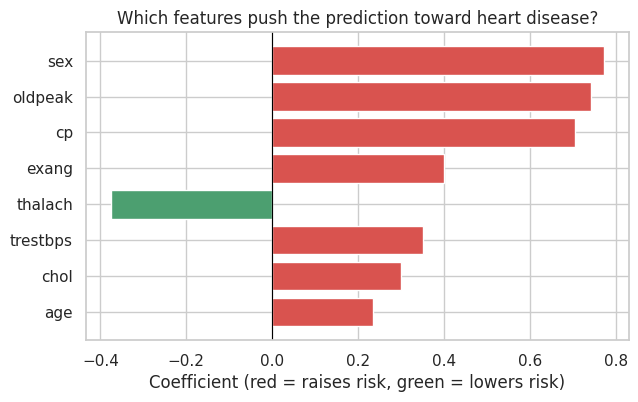

In [17]:
colors = ['#D9534F' if c > 0 else '#4C9F70' for c in coef_table['coefficient']]

plt.figure(figsize=(7, 4))
plt.barh(coef_table['feature'], coef_table['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Which features push the prediction toward heart disease?')
plt.xlabel('Coefficient (red = raises risk, green = lowers risk)')
plt.gca().invert_yaxis()
plt.show()

### 4c. Connect it back to the clinic

Look at your top three features by absolute coefficient. For each one, ask:

1. Does this match what a doctor would expect to matter for heart disease?
2. If the model relied heavily on this feature alone, would that worry you?
3. What might be missing from the dataset that a real cardiologist would also want to know?

---
## Reflection

Write a short answer (2–4 sentences) for each prompt in the cell below.

1. **Metric choice.** If you were the lead analyst pitching this tool to the
   hospital, which metric — accuracy, precision, or recall — would you put on
   the front page of your report, and why?

2. **Trust.** Suppose the model flags a 40-year-old patient with no obvious
   symptoms as high risk. What would you want the doctor to do *before* acting
   on the model's output? Why does human-in-the-loop review matter here?

3. **Data quality and bias.** This dataset comes mostly from one hospital in
   Cleveland and is several decades old. Name one way that could make the model
   perform worse on today's patients in Huntsville.

4. **Features.** Re-train the model with a different feature list (delete the
   strongest feature, or add `ca` and `thal`). What happened to recall? What
   does that tell you about how much any single feature drives the prediction?

In [18]:
# Type your reflection answers here, or write them in a separate document.
reflection = '''
1. ...
2. ...
3. ...
4. ...
'''
print(reflection)


1. ...
2. ...
3. ...
4. ...



---
## Stretch goals (optional)

Finished early? Pick one:

- 🔬 **Compare models.** Train a `DecisionTreeClassifier` or `RandomForestClassifier`
  on the same data. Which one has the best recall?
- 🎚️ **Tune the threshold.** By default the model predicts 'disease' when the
  probability is above 0.5. Try lowering it to 0.3. How do precision and recall change?
- 🩻 **Per-patient explanation.** Pick one test patient. Print their features and
  the model's predicted probability. Could you explain that prediction to them
  in plain language?

---
**End of lab.** Save your notebook (`File → Save`) and submit it as instructed
by your teacher. Great work — you just built and evaluated a real machine
learning model on real medical data.